# twixtools: Recon code

In [1]:
%matplotlib inline
import twixtools
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import torch
import json
from mirtorch_pkg import NuSense_om
from torchkbnufft import calc_density_compensation_function
import Nufftbindings.nufftbindings.kbnufft as kbnufft

main_dir = '/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit/MRSI_trajs/data/4Riccardo'
file_name = 'meas_MID00205_FID11344_ad_edMrsi_waterRef_20260521_0535.dat'
dcfnet_path = f'/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit/trained_models/dcfnet_512_unet_trained_with_E.pt'
pathTrjRef = "kspace_res50_bw2000Hz_ptls80.mat"
saving_folder = '/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit/MRSI_trajs/rosette/reconstructions'
os.makedirs(saving_folder, exist_ok=True)

folder_modules= os.path.abspath('/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit') 
if folder_modules not in sys.path:
    sys.path.append(folder_modules)

# from utils_3 import ImageRecon
from params import *
from models import UNet1D

## `read_twix`: Direct access to the raw data

`read_twix` provides low-level access to the Siemens MRI raw data, on a block-by-block ("mdb") level.

    Parameters
    ----------
    infile : filename or measurement id of .dat file
    include_scans: list of scan numbers or None, optional
        By default, all scans in a multi-raid file are parsed.
    parse_prot : bool, optional
        By default, the protocol information is parsed.
        (this is also highly recommended)
    parse_data: bool, optional
        Set to False to parse only protocol information.
    parse_geometry: bool, optional
        Set to False to skip creation of transformation matrix from data
        coordinates to physical coordinates.
    verbose: bool, optional
        Switch progress and other messages on or off.
    keep_acqend : bool, optional
        By default, acqend blocks are not included in the mdb list.
        This block is helpful for twix writing, but unnecessary otherwise.
    keep_syncdata : bool, optional
        By default, syncdata blocks are included in the mdb list.
        These blocks may include physio. (PMU) or trajectory information.

    Returns
    -------
    out: list of twix scan(s)
        The twix scans themselves consist of a dict with these elements:
            - hdr: dict of parsed ascconv and XProtocol header information
            - hdr_str: header bytearray (used by write_twix)
            - mdb: list of measurement data blocks -- here is the MRI data
              use `help(twixtools.mdb.Mdb)` for more information
            - geometry: dict containing geometry information about the scan
              use `help(twixtools.geometry)` for more information

In [2]:
# parse the twix file
twix = twixtools.read_twix(os.path.join(main_dir, file_name))

# twix is a list of measurements:
print('\nnumber of separate scans (multi-raid):', len(twix))

# sort all 'imaging' mdbs into a k-space array
image_mdbs = [mdb for mdb in twix[-1]['mdb'] if mdb.is_image_scan()]
print(f"Number of petals: {len(image_mdbs)}") 
print(f"Shape of each petal: {image_mdbs[0].data.shape}") 

Software version: VD/VE (!?)

Scan  0


100%|██████████| 32.3M/32.3M [00:00<00:00, 1.78GB/s]


Scan  1


100%|██████████| 641M/641M [00:00<00:00, 1.67GB/s]


number of separate scans (multi-raid): 2
Number of petals: 80
Shape of each petal: (32, 32704)


## Correct shape for the k-space input

In [3]:
N_PETALS = 80
N_COILS = 32
N_POINTS_PER_PETAL = 100
N_REPEATS = 325
petal_order = np.r_[np.arange(0, N_PETALS, 2), np.arange(1, N_PETALS, 2)]

data_raw = np.array([mdb.data for mdb in image_mdbs])
print(f"Raw stacked shape: {data_raw.shape}") 
# Output: (80, 32, 32704)

# 42 extra points at the beginning are not valid
data_valid = data_raw[:, :, 42:]
print(f"Shape after discarding initial 42 points: {data_valid.shape}")

# We discard last points to get 32500 (100 x 325) valid points per petal
data_valid = data_valid[:, :, :32500]
print(f"Final shape: {data_valid.shape}")

data = data_valid.reshape(N_PETALS, N_COILS, N_REPEATS, N_POINTS_PER_PETAL)

# sort data
# data_resorted = data[petal_order, :, :, :]      # (80, 32, 325, 100)
data_t0 = data[:, :, 0, :]             # (80, 32, 100)
data_flat = data_t0.transpose(1, 0, 2).reshape(N_COILS, -1)

print("flat:", data_flat.shape)

sampled_tensor = torch.tensor(data_flat, dtype=torch.complex64)  # shape: (32, 8000)
print(f"sampled tensor shape: {sampled_tensor.shape}")

Raw stacked shape: (80, 32, 32704)
Shape after discarding initial 42 points: (80, 32, 32662)
Final shape: (80, 32, 32500)
flat: (32, 8000)
sampled tensor shape: torch.Size([32, 8000])


## Reconstruction

### Rosette trajectory

kxx orig shape: (80, 100), kyy orig shape: (80, 100)
kxx resort shape: (80, 100), kyy resort shape: (80, 100)
rosette orig tensor shape: torch.Size([8000, 2])
rosette resort tensor shape: torch.Size([8000, 2])


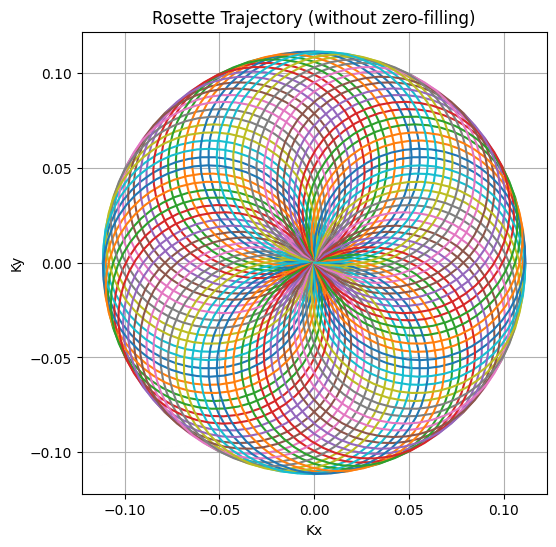

In [4]:
from scipy.io import loadmat
import numpy as np

dataTrjRef = loadmat(pathTrjRef)

Kxy_smp = dataTrjRef["Kxy_smp"]   # shape: (100, 80)
Kmax = float(dataTrjRef["Kmax"].squeeze())
kxx_orig = np.real(Kxy_smp) / Kmax * kmax_traj  # shape: (100, 80)
kyy_orig = np.imag(Kxy_smp) / Kmax * kmax_traj  # shape: (100, 80)

kxx_resort = kxx_orig[:, petal_order].T # shape: (80, 100)
kyy_resort = kyy_orig[:, petal_order].T # shape: (80, 100)
kxx_orig = kxx_orig.T  # shape: (80, 100)
kyy_orig = kyy_orig.T  # shape: (80, 100)

print(f"kxx orig shape: {kxx_orig.shape}, kyy orig shape: {kyy_orig.shape}")
print(f"kxx resort shape: {kxx_resort.shape}, kyy resort shape: {kyy_resort.shape}")

rosette_orig_tensor = torch.tensor(np.stack((kxx_orig, kyy_orig), axis=-1), dtype=torch.float32)  # shape: (80, 100, 2)
rosette_resort_tensor = torch.tensor(np.stack((kxx_resort, kyy_resort), axis=-1), dtype=torch.float32)  # shape: (80, 100, 2)
rosette_orig_tensor = rosette_orig_tensor.reshape(-1, 2)
rosette_resort_tensor = rosette_resort_tensor.reshape(-1, 2)
print(f"rosette orig tensor shape: {rosette_orig_tensor.shape}")
print(f"rosette resort tensor shape: {rosette_resort_tensor.shape}")

plt.figure(figsize=[6,6])
for i in range(80):
    plt.plot(kxx_resort[i], kyy_resort[i])
plt.title('Rosette Trajectory (without zero-filling)')
plt.xlabel('Kx')
plt.ylabel('Ky')
plt.axis('equal')
plt.grid()
plt.show()

### Image

In [5]:
# zero-filling
def add_zero_filling_to_rosette(rosette, kmax_img):
    corners = torch.tensor(
        [[kmax_img, kmax_img],
         [-kmax_img, -kmax_img]],
        dtype=rosette.dtype,
        device=rosette.device,
    )
    return torch.cat([rosette, corners], dim=0)

def add_zero_filling_to_samples(sampled):
    zeros = torch.zeros(
        2,
        dtype=sampled.dtype,
        device=sampled.device,
    )
    return torch.cat([sampled, zeros], dim=0)

In [6]:
def get_device():
    import torch

    if torch.cuda.is_available():
        return torch.device("cuda")
    # Disable MPS due to memory constraints - use CPU instead
    # elif torch.backends.mps.is_available():
    #     return torch.device("mps")
    else:
        return torch.device("cpu")
    
class ImageRecon:
    def __init__(self, params, kmax_img, dcfnet_path):
        self.device = get_device()
        self.kmax_img = kmax_img
        self.img_size = params["img_size"]
        self.timesteps = params["timesteps"]
        self.zero_filling = params["zero_filling"]
        self.n_petals = params["n_petals"]
        dcfdict, kernel_size, features = torch.load(dcfnet_path, map_location=self.device)
        self.dcfnet = UNet1D(in_channels=2, out_channels=1, features=features, kernel_size=kernel_size)
        self.dcfnet.load_state_dict(dcfdict)
        self.dcfnet.to(self.device)

    def reconstruct_img_mirtorch(self, rosette_orig, rosette_sorted, sampled):
        sampled = sampled.reshape(1, 1, -1)

        s0 = torch.ones(1, 1,int(self.img_size),int(self.img_size),device=sampled.device) + 0j

        rosette_orig = rosette_orig.squeeze().permute(1, 0) / self.kmax_img * torch.pi
        rosette_sorted = rosette_sorted.squeeze().permute(1, 0) / self.kmax_img * torch.pi

        Nop_orig = NuSense_om(s0,rosette_orig.reshape(1, 2, -1),norm=None)

        Nop_sorted = NuSense_om(s0,rosette_sorted.reshape(1, 2, -1),norm=None)

        # DCF is computed in original order, including zero-fill points
        dcf = calc_density_compensation_function(rosette_orig, (int(self.img_size), int(self.img_size))) + 0j

        # Normalize DCF in original order
        dcf = self.normalize_dcf_mirtorch(dcf.view(1, 1, -1),Nop_orig)

        # Reorder DCF
        dcf_real = dcf[..., :-2]
        dcf_zf = dcf[..., -2:]

        n_points_per_petal = dcf_real.shape[-1] // self.n_petals

        dcf_real = (dcf_real.view(1, self.n_petals, n_points_per_petal)[:, petal_order, :].reshape(1, 1, -1))
        dcf = torch.cat([dcf_real, dcf_zf], dim=-1)

        # Final reconstruction uses sorted rosette + sorted DCF + sampled
        I0 = Nop_sorted.H * (dcf * sampled)
        I0 = torch.flip(torch.rot90(I0.abs(), k=1, dims=(2, 3)),dims=[2]).squeeze()

        return dcf, I0

    def reconstruct_img_dcfnet(self, rosette_orig, rosette_sorted, sampled):
        rosette_orig = rosette_orig.squeeze() / self.kmax_img * torch.pi
        rosette_sorted = rosette_sorted.squeeze() / self.kmax_img * torch.pi

        sampled = sampled.reshape(1, 1, -1)

        kbnufft.nufft.set_dims(sampled.shape[-1],(int(self.img_size), int(self.img_size)),device=rosette_sorted.device,Nb=1)

        # DCFNet on original order taking into account zero-filling [:-2, :]
        dcf = self.dcfnet(rosette_orig[:-2, :].permute(1, 0).unsqueeze(0)).squeeze() + 0j

        # zero filling for DCF
        dcf = torch.cat([dcf, torch.zeros(2, dtype=dcf.dtype, device=dcf.device)],dim=-1,)

        # precompute on original rosette
        kbnufft.nufft.precompute(rosette_orig)

        dcf = self.normalize_dcf(dcf.view(1, 1, -1),rosette_orig,(int(self.img_size), int(self.img_size)))

        dcf_real = dcf[..., :-2]
        dcf_zf = dcf[..., -2:]

        # sorted dcf
        n_points_per_petal = dcf_real.shape[-1] // self.n_petals

        dcf_real_sorted = (dcf_real.view(1, self.n_petals, n_points_per_petal)[:, petal_order, :].reshape(1, 1, -1))
        dcf_sorted = torch.cat([dcf_real_sorted, dcf_zf], dim=-1)

        # precompute of sorted rosette
        kbnufft.nufft.precompute(rosette_sorted)

        I0 = kbnufft.adjoint(rosette_sorted,(sampled * dcf_sorted).squeeze(0)).unsqueeze(0)
        I0 = torch.flip( torch.rot90(I0.abs(), k=1, dims=(2, 3)),dims=[2]).squeeze()

        return dcf, I0

    def normalize_dcf(self, dcf, ktraj, im_size):
        x = torch.ones(1, *im_size, device=dcf.device) + 0j
        k = kbnufft.forward(ktraj, x)
        x_rec = kbnufft.adjoint(ktraj, k * dcf.squeeze(0)).abs()
        scale = x_rec.sum() / (x_rec**2).sum()
        return dcf * scale

    def normalize_dcf_mirtorch(self, dcf, Nop):
        x = torch.ones(1, 1, self.img_size, self.img_size, device=dcf.device) + 0j
        k = Nop * x
        x_rec = Nop.H * (dcf * k)
        scale = x_rec.sum() / (x_rec**2).sum()
        return dcf * scale

### new image resolution

In [7]:
print(f"Max k-space value in trajectory: {torch.abs(rosette_resort_tensor).max():.4f}")
new_resolution = int(np.round(torch.abs(rosette_resort_tensor).max() * 2 * params["FoV"]))
print(f"Nominal resolution : {new_resolution:.0f} x {new_resolution:.0f}")
new_resolution_mm = params['FoV'] / new_resolution
print(f"Nominal resolution in mm2: {new_resolution_mm:.2f} x {new_resolution_mm:.2f} mm2")

recon = ImageRecon(params, kmax_img, dcfnet_path)  

# zero-filling
rosette_orig_zf = add_zero_filling_to_rosette(rosette_orig_tensor.to(recon.device), kmax_img)
rosette_resort_zf = add_zero_filling_to_rosette(rosette_resort_tensor.to(recon.device), kmax_img)

print("rosette_orig_zf:", rosette_orig_zf.shape)
print("rosette_resort_zf:", rosette_resort_zf.shape) 

Max k-space value in trajectory: 0.1116
Nominal resolution : 50 x 50
Nominal resolution in mm2: 4.48 x 4.48 mm2
rosette_orig_zf: torch.Size([8002, 2])
rosette_resort_zf: torch.Size([8002, 2])


/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit/venv/lib/python3.12/site-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Max pixel value in DCFNet reconstruction: 5.789613715023734e-05
Max pixel value in MIRTorch reconstruction: 4.090302900294773e-05
Min pixel value in DCFNet reconstruction: 7.28067675481725e-07
Min pixel value in MIRTorch reconstruction: 2.894217914217734e-07


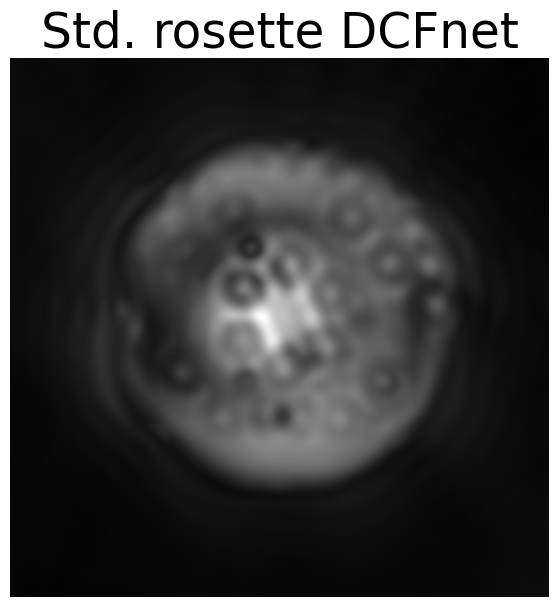

In [8]:
images_coils = []
for i in range(N_COILS):
    sampled_zf = add_zero_filling_to_samples(sampled_tensor[i].to(recon.device))
    _, image_coil = recon.reconstruct_img_dcfnet(rosette_orig_zf, rosette_resort_zf, sampled_zf)
    images_coils.append(image_coil.detach().cpu().numpy())

images_coils = np.array(images_coils)
image_rss_dcfnet = np.sqrt(np.sum(np.abs(images_coils)**2, axis=0))

images_coils = []
for i in range(N_COILS):
    sampled_zf = add_zero_filling_to_samples(sampled_tensor[i].to(recon.device))
    _, image_coil = recon.reconstruct_img_mirtorch(rosette_orig_zf, rosette_resort_zf, sampled_zf)
    images_coils.append(image_coil.detach().cpu().numpy())

images_coils = np.array(images_coils)
image_rss_mirtorch = np.sqrt(np.sum(np.abs(images_coils)**2, axis=0))

print(f"Max pixel value in DCFNet reconstruction: {image_rss_dcfnet.max()}")
print(f"Max pixel value in MIRTorch reconstruction: {image_rss_mirtorch.max()}")

print(f"Min pixel value in DCFNet reconstruction: {image_rss_dcfnet.min()}")
print(f"Min pixel value in MIRTorch reconstruction: {image_rss_mirtorch.min()}")
i_max = max(image_rss_dcfnet.max(), image_rss_mirtorch.max())

plt.figure(figsize=[7,7])
plt.imshow(image_rss_dcfnet, cmap="gray", origin="lower", vmin=0, vmax=i_max)
plt.title(f"Std. rosette DCFnet", size=35)
"""
plt.text(
    0.98, 0.02,
    f"Nominal res. = {new_resolution:.0f}x{new_resolution:.0f}, {new_resolution_mm:.2f}x{new_resolution_mm:.2f} mm$^2$",
    transform=plt.gca().transAxes,
    ha="right",
    va="bottom",
    fontsize=16,
    color="white",
    bbox=dict(
        facecolor="none",
        alpha=0.6,
        edgecolor="none",
        boxstyle="round,pad=0.3"
    )
)
"""
plt.axis("off")
plt.savefig(f"{saving_folder}/dcfnet.png", bbox_inches="tight", pad_inches=0, dpi=300)
plt.show()

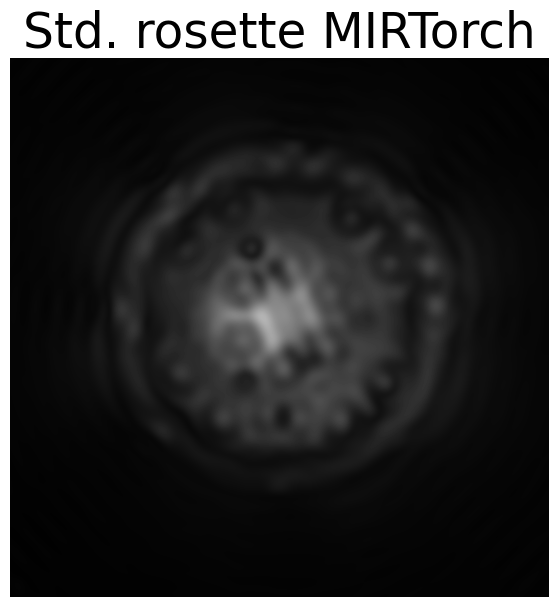

In [9]:
plt.figure(figsize=(7, 7))
plt.imshow(image_rss_mirtorch, cmap="gray", origin="lower", vmin=0, vmax=i_max)
plt.title(f"Std. rosette MIRTorch", size=35)
"""
plt.text(
    0.98, 0.02,
    f"Nominal res. = {new_resolution:.0f}x{new_resolution:.0f}, {new_resolution_mm:.2f}x{new_resolution_mm:.2f} mm$^2$",
    transform=plt.gca().transAxes,
    ha="right",
    va="bottom",
    fontsize=16,
    color="white",
    bbox=dict(
        facecolor="none",
        alpha=0.6,
        edgecolor="none",
        boxstyle="round,pad=0.3"
    )
)
"""
plt.axis("off")
plt.savefig(f"{saving_folder}/mirtorch.png", bbox_inches='tight', pad_inches=0)
plt.show()

### dcfnet E

In [10]:
import torchkbnufft as tkbn

# adapted from dcf_utils to take into account the new shapes of w and ktraj
def calculate_pipe_E(w_pred, ktraj, img_size, device):
    """
    Computes E = |A A^H W| to evaluate DCF quality.

    Expected shapes:
      w_pred: (1, 1, N)
      ktraj:  (N, 2)
    """

    im_shape = (img_size, img_size)

    fwd_op = tkbn.KbNufft(im_size=im_shape).to(device)
    adj_op = tkbn.KbNufftAdjoint(im_size=im_shape).to(device)

    w_pred = w_pred.to(device)          # (1, 1, N)
    ktraj = ktraj.to(device)            # (N, 2)

    # ktraj from (N, 2) to (2, N)
    ktraj = ktraj.T.contiguous()        # (2, N)

    # DCF weights to complex
    w_complex = torch.complex(w_pred, torch.zeros_like(w_pred))  # (1, 1, N)

    # A^H W, then A A^H W
    grid_density = adj_op(w_complex, ktraj)
    E_complex = fwd_op(grid_density, ktraj)

    return E_complex.abs().squeeze(1)   # (1, N)


def plot_E_colormap(E, ktraj, title=r"$E = |A A^H W|$", delta=None):

    kx = ktraj[:, 0].detach().cpu().numpy()
    ky = ktraj[:, 1].detach().cpu().numpy()
    e_vals = E.detach().cpu().numpy()

    # max distance from 1
    if delta is None:
        delta = np.nanmax(np.abs(e_vals - 1.0))

    vmin = 1.0 - delta
    vmax = 1.0 + delta

    plt.figure(figsize=(6, 5))
    sc = plt.scatter(kx,ky,c=e_vals,cmap="coolwarm",s=0.5,vmin=vmin,vmax=vmax)
    plt.title(title)
    plt.axis("equal")
    plt.colorbar(sc, ax=plt.gca(), label="E")
    plt.tight_layout()
    plt.show()

Calculated DCF shape: torch.Size([1, 1, 8002])
Shape of rosette resort tensor: torch.Size([8002, 2])
E_raw shape: torch.Size([1, 8002])
E_normalized shape: torch.Size([1, 8002])


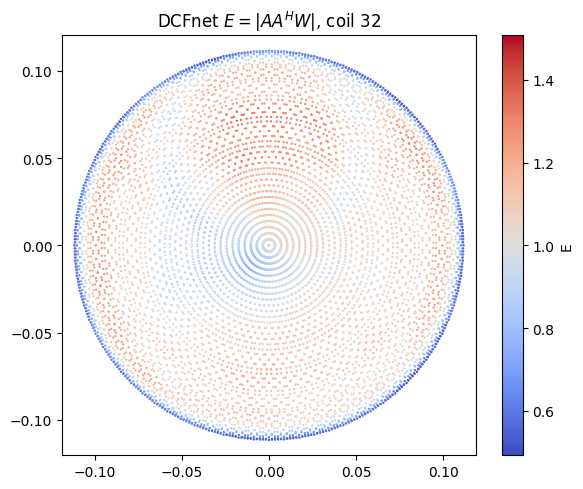

In [11]:
folder_modules = os.path.abspath('/Users/Riccardo_1/Desktop/EPFL/MRI/MR_Trajectory_Fit/dcf_generation')
if folder_modules not in sys.path:
    sys.path.append(folder_modules)

dcf, image_coil = recon.reconstruct_img_dcfnet(rosette_orig_zf, rosette_resort_zf, sampled_zf) #last coil

print(f"Calculated DCF shape: {dcf.shape}")
print(f"Shape of rosette resort tensor: {rosette_resort_zf.shape}")
with torch.no_grad():
    E_raw = calculate_pipe_E(
        dcf.real,
        rosette_resort_zf,
        params["img_size"],
        device=recon.device
    )

    # Normalize over samples, not over batch
    E_normalized_dcf = E_raw / (E_raw.mean(dim=-1, keepdim=True) + 1e-8)

    print("E_raw shape:", E_raw.shape)
    print("E_normalized shape:", E_normalized_dcf.shape)

    plot_E_colormap(E_normalized_dcf[:, :-2], rosette_resort_zf[:-2, :], title=r"DCFnet $E = |A A^H W|$, coil 32")


### mirtorch E

Calculated DCF shape: torch.Size([1, 1, 8002])
Shape of rosette resort tensor: torch.Size([8002, 2])
E_raw shape: torch.Size([1, 8002])
E_normalized shape: torch.Size([1, 8002])


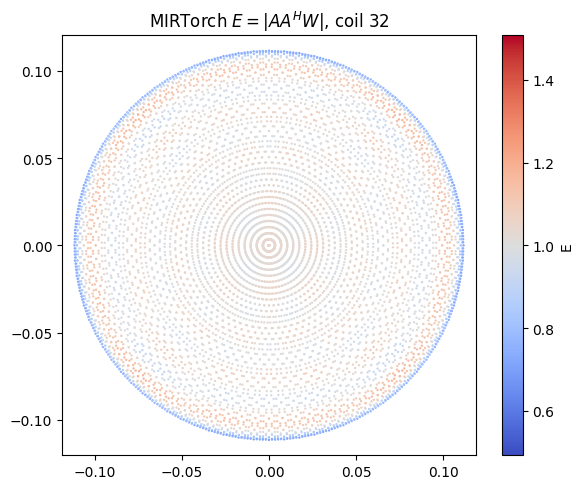

In [12]:
dcf, image_coil = recon.reconstruct_img_mirtorch(rosette_orig_zf, rosette_resort_zf, sampled_zf) #last coil

print(f"Calculated DCF shape: {dcf.shape}")
print(f"Shape of rosette resort tensor: {rosette_resort_zf.shape}")
with torch.no_grad():
    E_raw = calculate_pipe_E(
        dcf.real,
        rosette_resort_zf,
        params["img_size"],
        device=recon.device
    )

    # Normalize over samples, not over batch
    E_normalized = E_raw / (E_raw.mean(dim=-1, keepdim=True) + 1e-8)

    print("E_raw shape:", E_raw.shape)
    print("E_normalized shape:", E_normalized.shape)

    plot_E_colormap(E_normalized[:, :-2], rosette_resort_zf[:-2, :], title=r"MIRTorch $E = |A A^H W|$, coil 32", delta = np.nanmax(np.abs(E_normalized_dcf[:, :-2].detach().cpu().numpy()
 - 1.0)))